In [1]:
from utils import calculate_nse, create_lag, create_lag_adv, create_lag_adv_corrected
from shap import initjs


initjs()

In [2]:
#tips
#for single column dataframes always use double brackets, single brackets will make it a series, or float type
# for adding two columns to a df either add them one by one or use two brackets

In [3]:
import pandas as pd
df = pd.read_csv('final_data_physics_baseline/phy_final_corrected_data.csv')
pd.to_datetime(df['date'])
df = df.set_index('date')
df.drop(columns= 'Unnamed: 0', inplace= True)
df.drop(columns= 'Unnamed: 0.1', inplace= True)

# we convert 0-12 to radians circle for a seasonal mapping (circular time encoding)
# ensure index is treated as datetime (works even if the Index is not recognized as DatetimeIndex)
import numpy as np
month = pd.DatetimeIndex(df.index).month

df['year_sin'] = np.sin(2*np.pi*month/12)
df['year_cos'] = np.cos(2*np.pi*month/12)


df1 = df.copy()
df.head()


,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff,year_sin,year_cos
date,,,,,,,,,,,
2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,5.271130,278.271130,0.959289,1.224647e-16,-1.000000e+00
2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,9.535170,282.535170,0.515886,-5.000000e-01,-8.660254e-01
2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,7.745643,280.745643,0.355015,-8.660254e-01,-5.000000e-01
2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,3.499669,276.499669,0.186357,-1.000000e+00,-1.836970e-16
2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.000000,268.727686,0.138155,-8.660254e-01,5.000000e-01


In [4]:
# # --- EDA: input variable time series + distributions + correlation heatmap ---
# # This cell is purely diagnostic; it does not change modeling.

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Prefer the raw dataframe (df1) if present; otherwise fall back to df
# _data = df1.copy() if 'df1' in globals() else df.copy()
# _data.index = pd.to_datetime(_data.index)

# # Candidate "input" columns (keep only those that exist)
# # Note: we exclude 'runoff' here by default since it is the target.
# candidate_inputs = [
#     'precipitation',
#     'et_loss',
#     'sca',
#     'dd',
#     'year_sin',
#     'year_cos',
# ]

# input_cols = [c for c in candidate_inputs if c in _data.columns]

# print('Input columns found:', input_cols)

# # 0) Time series plots (variable vs time)
# if len(input_cols) > 0:
#     n = len(input_cols)
#     ncols = 2
#     nrows = int(np.ceil(n / ncols))

#     fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), dpi=120, sharex=True)
#     axes = np.array(axes).reshape(-1)

#     for ax, col in zip(axes, input_cols):
#         s = pd.to_numeric(_data[col], errors='coerce')
#         ax.plot(_data.index, s, linewidth=0.9, alpha=0.9, color='#4c78a8')
#         ax.set_title(col)
#         ax.grid(True, alpha=0.25)

#     for ax in axes[len(input_cols):]:
#         ax.set_axis_off()

#     plt.suptitle('Input Variables Over Time', y=1.02, fontsize=14)
#     plt.tight_layout()
#     plt.show()

# # 1) Correlation heatmap (inputs only)
# if len(input_cols) >= 2:
#     corr = _data[input_cols].corr(numeric_only=True)
#     plt.figure(figsize=(1.2 * len(input_cols) + 4, 1.0 * len(input_cols) + 3))
#     sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True)
#     plt.title('Input Feature Correlation Heatmap')
#     plt.tight_layout()
#     plt.show()
# else:
#     print('Not enough input columns found to compute a correlation heatmap:', input_cols)

# # 2) Distribution plots (hist + KDE)
# if len(input_cols) > 0:
#     n = len(input_cols)
#     ncols = 3
#     nrows = int(np.ceil(n / ncols))

#     fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), dpi=120)
#     axes = np.array(axes).reshape(-1)

#     for ax, col in zip(axes, input_cols):
#         series = pd.to_numeric(_data[col], errors='coerce').dropna()
#         if series.empty:
#             ax.set_axis_off()
#             continue
#         sns.histplot(series, bins=30, kde=True, ax=ax, color='#4c78a8')
#         ax.set_title(f'Distribution: {col}')

#     # hide any unused axes
#     for ax in axes[len(input_cols):]:
#         ax.set_axis_off()

#     plt.tight_layout()
#     plt.show()

# # 3) Boxplots by month (seasonality sanity check; optional)
# # Useful to verify that dd and sca have expected annual cycles.
# if 'month' not in _data.columns:
#     _data['_month'] = _data.index.month
# else:
#     _data['_month'] = _data['month']

# season_cols = [c for c in ['dd', 'sca', 'precipitation', 'et_loss'] if c in _data.columns]
# if len(season_cols) > 0:
#     fig, axes = plt.subplots(len(season_cols), 1, figsize=(12, 3 * len(season_cols)), dpi=120)
#     if len(season_cols) == 1:
#         axes = [axes]

#     for ax, col in zip(axes, season_cols):
#         sns.boxplot(data=_data, x='_month', y=col, ax=ax, color='#9ecae9')
#         ax.set_title(f'{col} by Month-of-Year')
#         ax.set_xlabel('Month')
#         ax.set_ylabel(col)

#     plt.tight_layout()
#     plt.show()

# # cleanup helper column
# _data.drop(columns=['_month'], inplxace=True, errors='ignore')


In [8]:
# #WITHOUT SEASON AWARENESS
# #train baseline prediction regression model only fitted on train data
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression
# # lag_scaler = StandardScaler()


# x_lagged = create_lag(df1, lag_precip=1, lag_dd=2, lag_sca=2, lag_et=1)

# x_train = x_lagged[:'2017-12-31']
# x_val = x_lagged['2018-01-01':'2021-12-31']
# x_test = x_lagged['2022-01-01':]

# y_train = x_lagged[:'2017-12-31']
# y_val = x_lagged['2018-01-01':'2021-12-31']
# y_test = x_lagged['2022-01-01':]

# X_train_lagged = x_train[[ 'sca_lagged','dd_lagged','melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# Y_train_lagged = y_train[['runoff']]
# Y_val_lagged = y_val[['runoff']]
# X_val_lagged = x_val[[ 'sca_lagged','dd_lagged','melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# X_test_lagged = x_test[['sca_lagged','dd_lagged','melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# Y_test_lagged = x_test[['runoff']]

# X_train_val = pd.concat([X_train_lagged, X_val_lagged])
# Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])
# x_lagged.head()
# # lag_scaler.fit(X_train_lagged)
 
# # x_train_scaled = lag_scaler.transform(X_train_lagged)
# # x_val_scaled = lag_scaler.transform(X_val_lagged)
# # x_test_scaled = lag_scaler.transform(X_test_lagged)

# model = LinearRegression()
# model.fit(X_train_lagged, Y_train_lagged)

# y_test_pred = model.predict(X_test_lagged)
# baseline_nse = calculate_nse(Y_test_lagged, y_test_pred)
# print(baseline_nse)
# # alpha, beta, gamma, delta=amodel.coef_
# print(model.coef_)

In [9]:
lag_dd = 2
lag_sca = 2
lag_et = 1
lag_precip = 1
df = create_lag(df,lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)

In [10]:
#train baseline prediction regression model only fitted on train data
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
# lag_scaler = StandardScaler()
lag_dd = 3
lag_sca = 3
lag_et = 2
lag_precip = 2

x_lagged = df1.copy()

x_t = x_lagged[:'2017-12-31']
x_v = x_lagged['2018-01-01':'2021-12-31']
x_te = x_lagged['2022-01-01':]

y_t = x_lagged[:'2017-12-31']
y_v = x_lagged['2018-01-01':'2021-12-31']
y_te = x_lagged['2022-01-01':]

x_train = create_lag(x_t, lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)
x_val = create_lag(x_v, lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)
x_test = create_lag(x_te, lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)

y_train = create_lag(x_t, lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)
y_val = create_lag(x_v, lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)
y_test = create_lag(x_te, lag_precip=lag_precip, lag_dd=lag_dd, lag_sca=lag_sca, lag_et=lag_et)

X_train_lagged = x_train[['sca_lagged','dd_lagged', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_train_lagged = y_train[['runoff']]
Y_val_lagged = y_val[['runoff']]
X_val_lagged = x_val[['sca_lagged','dd_lagged', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
X_test_lagged = x_test[['sca_lagged','dd_lagged', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_test_lagged = x_test[['runoff']]

X_train_val = pd.concat([X_train_lagged, X_val_lagged])
Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])
x_lagged.head()
# lag_scaler.fit(X_train_lagged)
 
# x_train_scaled = lag_scaler.transform(X_train_lagged)
# x_val_scaled = lag_scaler.transform(X_val_lagged)
# x_test_scaled = lag_scaler.transform(X_test_lagged)
# x_val_lagged
seasonaware_model = LinearRegression()
seasonaware_model.fit(X_train_lagged, Y_train_lagged)

y_val_pred = seasonaware_model.predict(X_val_lagged)
baseline_nse_val = calculate_nse(Y_val_lagged, y_val_pred)
print(baseline_nse_val)
# alpha, beta, gamma, delta=amodel.coef_
print(seasonaware_model.coef_)

runoff    0.437728
dtype: float64
[[ 6.07541770e-06 -2.40785957e-02 -1.35175691e-06  1.69999234e+01
   2.99319002e-01]]


/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sca_lagged'] = df['sca'].shift(lag_sca)
/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dd_lagged'] = df['dd'].shift(lag_dd)
/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [11]:
# #train baseline prediction regression model only fitted on train data
# from re import X
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression
# # lag_scaler = StandardScaler()


# x_lagged = df1.copy()

# x_t = x_lagged[:'2017-12-31']
# x_v = x_lagged['2018-01-01':'2021-12-31']
# x_te = x_lagged['2022-01-01':]

# y_t = x_lagged[:'2017-12-31']
# y_v = x_lagged['2018-01-01':'2021-12-31']
# y_te = x_lagged['2022-01-01':]

# x_train = create_lag(x_t, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
# x_val = create_lag(x_v, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
# x_test = create_lag(x_te, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

# y_train = create_lag(x_t, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
# y_val = create_lag(x_v, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
# y_test = create_lag(x_te, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

# X_train_lagged = x_train[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# Y_train_lagged = y_train[['runoff']]
# Y_val_lagged = y_val[['runoff']]
# X_val_lagged = x_val[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# X_test_lagged = x_test[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# Y_test_lagged = x_test[['runoff']]

# X_train_val = pd.concat([X_train_lagged, X_val_lagged])
# Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])
# x_lagged.head()
# lag_scaler.fit(X_train_lagged)
 
# x_train_scaled = lag_scaler.transform(X_train_lagged)
# x_val_scaled = lag_scaler.transform(X_val_lagged)
# x_test_scaled = lag_scaler.transform(X_test_lagged)

seasonaware_model = LinearRegression()
seasonaware_model.fit(X_train_lagged, Y_train_lagged)

y_test_pred = seasonaware_model.predict(X_test_lagged)
baseline_nse = calculate_nse(Y_test_lagged, y_test_pred)
print(baseline_nse)
# alpha, beta, gamma, delta=amodel.coef_
print(seasonaware_model.coef_)

runoff    0.493534
dtype: float64
[[ 6.07541770e-06 -2.40785957e-02 -1.35175691e-06  1.69999234e+01
   2.99319002e-01]]


/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [12]:
train_preds = seasonaware_model.predict(X_train_lagged)
val_preds = seasonaware_model.predict(X_val_lagged)
test_preds = seasonaware_model.predict(X_test_lagged)

#recombination
baseline_q_no_leak = pd.concat([
    pd.DataFrame(train_preds, index=X_train_lagged.index, columns=['baseline_q']),
    pd.DataFrame(val_preds, index=X_val_lagged.index, columns=['baseline_q']),
    pd.DataFrame(test_preds, index=X_test_lagged.index, columns=['baseline_q'])
])
Y_full = pd.concat([Y_train_val, Y_test_lagged])

df_full = pd.concat([X_train_lagged, X_val_lagged, X_test_lagged])
df_full['baseline_q'] = baseline_q_no_leak
df_full['residuals'] = Y_full['runoff'] - df_full['baseline_q']

df_adv = create_lag_adv_corrected(df1) 
df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()

/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_


In [13]:
# from xgboost import XGBRegressor
# import pandas as pd

# xgb = XGBRegressor(
#     max_depth=5,
#     learning_rate=0.01,
#     n_estimators=1500,
#     random_state=42, # Add for reproducibility
# )

# train_ml = df_adv[:'2017-12-31']
# val_ml = df_adv['2018-01-01':'2021-12-31']
# test_ml = df_adv['2022-01-01':]

# X_train_ml = train_ml.drop(columns=['baseline_q', 'residuals'])
# y_train_ml = train_ml['residuals']

# X_val_ml = val_ml.drop(columns=['baseline_q', 'residuals'])
# y_val_ml = val_ml['residuals']

# # 4. Fit the model ONLY on the training data
# xgb.fit(X_train_ml, y_train_ml)

# # 5. Predict on the validation set
# residual_pred_val = xgb.predict(X_val_ml)
# q_hybrid_val = residual_pred_val + val_ml['baseline_q']

# # 6. Evaluate against the correct validation ground truth
# y_val_true = Y_full['runoff'].loc[val_ml.index]
# hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_val)

# print(f"Hybrid NSE (Validation): {hybrid_nse_val:.4f}")


In [14]:
# # --- Final Test Set Evaluation --- train model on train + val data

# # Prepare combined training/validation data
# X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
# y_train_val_ml = pd.concat([y_train_ml, y_val_ml])

# # Prepare test data
# X_test_ml = test_ml.drop(columns=['baseline_q', 'residuals'])

# # Re-fit the model on all available training data
# xgb.fit(X_train_val_ml, y_train_val_ml)

# # Predict on the test set
# residual_pred_test = xgb.predict(X_test_ml)
# q_hybrid_test = residual_pred_test + test_ml['baseline_q']

# # Evaluate against the test ground truth
# y_test_true = Y_full['runoff'].loc[test_ml.index]
# hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_test)

# print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

In [15]:

df_adv = create_lag_adv_corrected(df1) 
df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()
df_adv.head()
# df_adv['year_sin'] = x_lagged['year_sin']
# df_adv['year_cos'] = x_lagged['year_cos']
col_names = df_adv.columns.tolist()
col_names

['sca_lagged',
 'dd_lagged',
 'et_loss_lagged',
 'melt_proxy',
 'precipitation_lagged',
 'sca_lagged_1',
 'dd_lagged_1',
 'sca_lagged_2',
 'dd_lagged_2',
 'sca_lagged_3',
 'dd_lagged_3',
 'sca_lagged_4',
 'dd_lagged_4',
 'sca_lagged_5',
 'dd_lagged_5',
 'sca_lagged_6',
 'dd_lagged_6',
 'sca_lagged_7',
 'dd_lagged_7',
 'et_loss_lagged_1',
 'precipitation_lagged_1',
 'melt_proxy_1_1',
 'melt_proxy_2_1',
 'melt_proxy_2_2',
 'melt_proxy_3_2',
 'melt_proxy_3_3',
 'melt_proxy_4_3',
 'melt_proxy_4_4',
 'melt_proxy_5_4',
 'melt_proxy_5_5',
 'melt_proxy_6_5',
 'melt_proxy_6_6',
 'melt_proxy_7_6',
 'melt_proxy_7_7',
 'baseline_q',
 'residuals']

In [16]:

# df_adv = create_lag_adv_corrected(df1) 
# df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()
# from xgboost import XGBRegressor
# import pandas as pd

# # --- FIX: Explicitly define the feature set to exclude current-day data ---
# # These are the features created by create_lag_adv_corrected
# lagged_feature_columns = [
#     'sca_lagged_1', 'sca_lagged_2',
#     'dd_lagged_1', 'dd_lagged_2',
#     'et_loss_lagged_1',
#     'precipitation_lagged_1',
#     'melt_proxy_1_1', 'melt_proxy_1_2',
#     'melt_proxy_2_1', 'melt_proxy_2_2'
# ]

# # These are the columns we want to predict or use in the final calculation
# target_and_baseline_cols = ['baseline_q', 'residuals']

# # The final dataframe for the ML model should ONLY contain these columns
# df_ml_final = df_adv[lagged_feature_columns+ target_and_baseline_cols]


# # --- Now proceed with the corrected dataframe ---
# xgb1 = XGBRegressor(
#     max_depth=5,
#     learning_rate=0.03,
#     n_estimators=1500,
#     random_state=42
# )

# # 1. Split the clean ML dataframe
# train_ml = df_ml_final[:'2017-12-31']
# val_ml = df_ml_final['2018-01-01':'2021-12-31']
# test_ml = df_ml_final['2022-01-01':]

# # 2. Prepare features and labels for validation
# X_train_ml = train_ml.drop(columns=target_and_baseline_cols)
# y_train_ml = train_ml['residuals']

# X_val_ml = val_ml.drop(columns=target_and_baseline_cols)

# # 3. Fit the model ONLY on the training data
# xgb1.fit(X_train_ml, y_train_ml)

# # 4. Predict on the validation set
# residual_pred_val = xgb1.predict(X_val_ml)
# q_hybrid_val = residual_pred_val + val_ml['baseline_q']

# # 5. Evaluate against the correct validation ground truth
# y_val_true = Y_full['runoff'].loc[val_ml.index]
# hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_val)

# print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# # --- Final Test Set Evaluation ---
# # Prepare combined training/validation data
# X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
# y_train_val_ml = pd.concat([y_train_ml, val_ml['residuals']])

# # Prepare test data
# X_test_ml = test_ml.drop(columns=target_and_baseline_cols)

# # Re-fit the model on all available training data
# xgb1.fit(X_train_val_ml, y_train_val_ml)

# # Predict on the test set
# residual_pred_test = xgb1.predict(X_test_ml)
# q_hybrid_test = residual_pred_test + test_ml['baseline_q']

# # Evaluate against the test ground truth
# y_test_true = Y_full['runoff'].loc[test_ml.index]
# hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_test)

# print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

In [17]:
df_features = df_adv.drop(columns=['residuals', 'baseline_q'])
df_features.head()

,sca_lagged,dd_lagged,et_loss_lagged,melt_proxy,precipitation_lagged,sca_lagged_1,dd_lagged_1,sca_lagged_2,dd_lagged_2,sca_lagged_3,...,melt_proxy_3_2,melt_proxy_3_3,melt_proxy_4_3,melt_proxy_4_4,melt_proxy_5_4,melt_proxy_5_5,melt_proxy_6_5,melt_proxy_6_6,melt_proxy_7_6,melt_proxy_7_7
date,,,,,,,,,,,,,,,,,,,,,
2001-01-31,21183.674218,0.0,0.026067,0.0,0.175427,36902.800385,0.0,21183.674218,0.0,19583.623736,...,0.0,0.0,0.0,45106.57075,35396.10795,78340.441997,47933.407883,59007.779814,149655.371310,82730.876936
2001-02-28,36902.800385,0.0,0.043346,0.0,0.063452,35286.368770,0.0,36902.800385,0.0,21183.674218,...,0.0,0.0,0.0,0.00000,0.00000,45106.570750,35396.107950,78340.441997,47933.407883,59007.779814
2001-03-31,35286.368770,0.0,0.035878,0.0,0.122006,25131.303245,0.0,35286.368770,0.0,36902.800385,...,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,45106.570750,35396.107950,78340.441997
2001-04-30,25131.303245,0.0,0.092487,0.0,0.349344,46124.160931,0.0,25131.303245,0.0,35286.368770,...,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,45106.570750
2001-05-31,46124.160931,0.0,0.095070,0.0,0.510792,34841.225052,0.0,46124.160931,0.0,25131.303245,...,0.0,0.0,0.0,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:

# from xgboost import XGBRegressor
# import pandas as pd

# # --- FIX: Explicitly define the feature set to exclude current-day data ---
# # These are the features created by create_lag_adv_corrected
# lagged_feature_columns =[
#  'et_loss_lagged_1',
#  'precipitation_lagged_1',
#  'melt_proxy_1_1',
#  'melt_proxy_2_1',
#  'melt_proxy_2_2',
#  'melt_proxy_3_2',
#  'melt_proxy_3_3',
#  'melt_proxy_4_3',
#  'melt_proxy_4_4',
#  'melt_proxy_5_4',
#  'melt_proxy_5_5',
#  'melt_proxy_6_5',
#  'melt_proxy_6_6',
#  'melt_proxy_7_6',
#  'melt_proxy_7_7',
#  'baseline_q',
#  'residuals',
# ]

# # These are the columns we want to predict or use in the final calculation
# target_and_baseline_cols = ['baseline_q', 'residuals']

# # The final dataframe for the ML model should ONLY contain these columns
# df_ml_final = df_adv[lagged_feature_columns]


# # --- Now proceed with the corrected dataframe ---
# xgb1 = XGBRegressor(
#     max_depth=5,
#     learning_rate=0.01,
#     n_estimators=1500,
#     random_state=42
# )

# # 1. Split the clean ML dataframe
# train_ml = df_ml_final[:'2017-12-31']
# val_ml = df_ml_final['2018-01-01':'2021-12-31']
# test_ml = df_ml_final['2022-01-01':]

# # 2. Prepare features and labels for validation
# X_train_ml = train_ml.drop(columns=target_and_baseline_cols)
# y_train_ml = train_ml['residuals']

# X_val_ml = val_ml.drop(columns=target_and_baseline_cols)

# # 3. Fit the model ONLY on the training data
# xgb1.fit(X_train_ml, y_train_ml)

# # 4. Predict on the validation set
# residual_pred_valf = xgb1.predict(X_val_ml)
# q_hybrid_valf = residual_pred_valf + val_ml['baseline_q']

# # 5. Evaluate against the correct validation ground truth
# y_val_true = Y_full['runoff'].loc[val_ml.index]
# hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_valf)

# print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# # --- Final Test Set Evaluation ---
# # Prepare combined training/validation data
# X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
# y_train_val_ml = pd.concat([y_train_ml, val_ml['residuals']])

# # Prepare test data
# X_test_ml = test_ml.drop(columns=target_and_baseline_cols)

# # Re-fit the model on all available training data
# xgb1.fit(X_train_val_ml, y_train_val_ml)

# # Predict on the test set
# residual_pred_testf = xgb1.predict(X_test_ml)
# q_hybrid_testf = residual_pred_testf + test_ml['baseline_q']

# # Evaluate against the test ground truth
# y_test_true = Y_full['runoff'].loc[test_ml.index]
# hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_testf)

# print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

In [28]:
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# --- XGBoost (leakage-free) on engineered lag features ---
# Fix for: AttributeError: 'DataFrame' object has no attribute 'dtype'
# This error is commonly triggered when the feature frame contains duplicate column names
# (pandas returns a DataFrame for X[col] when col is duplicated; XGBoost expects a Series -> has .dtype).

# 1) Build a clean, de-duplicated feature list
lagged_feature_columns = [
    'sca_lagged_1','dd_lagged_1',
    'sca_lagged_2','dd_lagged_2',
    'et_loss_lagged_1',
    'precipitation_lagged_1',
    'melt_proxy_1_1',
    'melt_proxy_2_1','melt_proxy_2_2',
    'baseline_q',
    'residuals',
]

# drop duplicates while preserving order
seen = set()
lagged_feature_columns = [c for c in lagged_feature_columns if not (c in seen or seen.add(c))]

# 2) Define target columns
target_and_baseline_cols = ['baseline_q', 'residuals']

# 3) Keep only columns that actually exist (avoid KeyError if upstream recipe changes)
existing_cols = [c for c in lagged_feature_columns if c in df_adv.columns]
missing = [c for c in lagged_feature_columns if c not in df_adv.columns]
if missing:
    print('Warning: missing expected columns dropped from model features:', missing)

df_ml_final = df_adv[existing_cols].copy()

# 4) Ensure we do not have duplicate columns in the frame
if df_ml_final.columns.duplicated().any():
    df_ml_final = df_ml_final.loc[:, ~df_ml_final.columns.duplicated()].copy()

# 5) Split
train_ml = df_ml_final[:'2017-12-31']
val_ml = df_ml_final['2018-01-01':'2021-12-31']
test_ml = df_ml_final['2022-01-01':]

# 6) Prepare features/labels
X_train_ml = train_ml.drop(columns=target_and_baseline_cols, errors='ignore')
y_train_ml = train_ml['residuals'].astype(float)

X_val_ml = val_ml.drop(columns=target_and_baseline_cols, errors='ignore')

# Coerce to numeric and drop any now-non-numeric features (defensive)
X_train_ml = X_train_ml.apply(pd.to_numeric, errors='coerce')
X_val_ml = X_val_ml.apply(pd.to_numeric, errors='coerce')

# Align columns exactly
X_val_ml = X_val_ml.reindex(columns=X_train_ml.columns)

# Fill NaNs (XGBoost can handle NaNs, but we keep it explicit)
X_train_ml = X_train_ml.astype(float)
X_val_ml = X_val_ml.astype(float)

# 7) Train
xgb2 = XGBRegressor(
    max_depth=6,
    learning_rate=0.01,
    n_estimators=1000,
    random_state=42,
    objective='reg:squarederror',
)

xgb2.fit(X_train_ml.to_numpy(), y_train_ml.to_numpy())

# 8) Validate
residual_pred_valf = xgb2.predict(X_val_ml.to_numpy())
q_hybrid_valf = residual_pred_valf + val_ml['baseline_q'].to_numpy()

y_val_true = Y_full['runoff'].loc[val_ml.index]
hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_valf)
print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# 9) Final test (train on train+val)
X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
y_train_val_ml = pd.concat([y_train_ml, val_ml['residuals'].astype(float)])

X_test_ml = test_ml.drop(columns=target_and_baseline_cols, errors='ignore')
X_test_ml = X_test_ml.apply(pd.to_numeric, errors='coerce').reindex(columns=X_train_ml.columns).astype(float)

xgb2.fit(X_train_val_ml.to_numpy(), y_train_val_ml.to_numpy())

residual_pred_testf = xgb2.predict(X_test_ml.to_numpy())
q_hybrid_testf = residual_pred_testf + test_ml['baseline_q'].to_numpy()

y_test_true = Y_full['runoff'].loc[test_ml.index]
hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_testf)
print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

Corrected Hybrid NSE (Validation): 0.2163
Final Hybrid NSE (Test): 0.2705


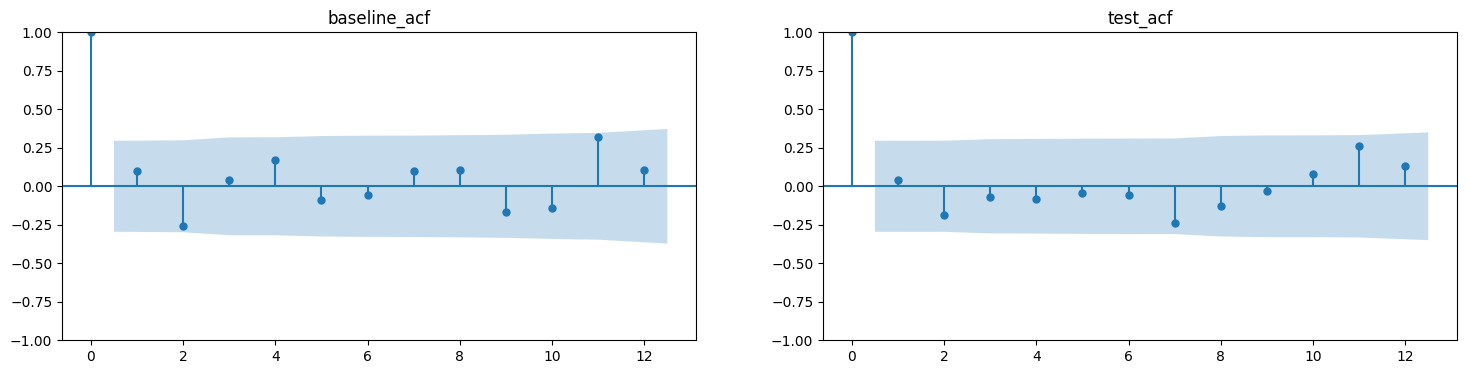

Durbin-Watson — Baseline: 1.754 | Hybrid: 1.863


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(1,2, figsize= (18, 4))
# plot_acf( residual_pred_valf, lags = 12, ax = axes[0], title = 'val_acf' )
plot_acf( test_ml['residuals'], lags = 12, ax = axes[0], title = 'baseline_acf' )
plot_acf(residual_pred_testf, lags=12, ax=axes[1], title='test_acf')

plt.savefig('acf_residuals.png', dpi=150)
plt.show()

# 2. Durbin-Watson statistic (quick scalar check)
dw_baseline = durbin_watson(test_ml['residuals'])
dw_hybrid   = durbin_watson(residual_pred_testf)

print(f"Durbin-Watson — Baseline: {dw_baseline:.3f} | Hybrid: {dw_hybrid:.3f}")
# ~2.0 = no autocorrelation, <1.5 = positive autocorrelation (bad), >2.5 = negative


In [22]:
# print(X_val_ml.iloc[0])
# print(val_ml['residuals'].iloc[0])
val_ml.count()

sca_lagged_1              45
dd_lagged_1               45
sca_lagged_2              45
dd_lagged_2               45
sca_lagged_3              45
dd_lagged_3               45
et_loss_lagged_1          45
precipitation_lagged_1    45
melt_proxy_1_1            45
melt_proxy_2_1            45
melt_proxy_2_2            45
melt_proxy_3_2            45
melt_proxy_3_3            45
baseline_q                45
residuals                 45
dtype: int64

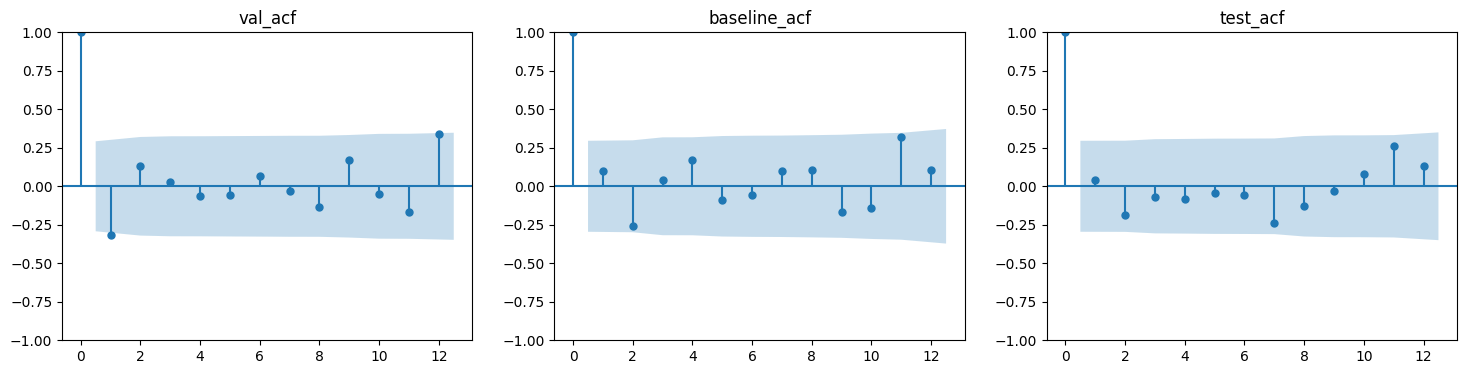

Durbin-Watson — Baseline: 1.754 | Hybrid: 1.863


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(1,3, figsize= (18, 4))
plot_acf( residual_pred_valf, lags = 12, ax = axes[0], title = 'val_acf' )
plot_acf( test_ml['residuals'], lags = 12, ax = axes[1], title = 'baseline_acf' )
plot_acf(residual_pred_testf, lags=12, ax=axes[2], title='test_acf')

plt.savefig('acf_residuals.png', dpi=150)
plt.show()

# 2. Durbin-Watson statistic (quick scalar check)
dw_baseline = durbin_watson(test_ml['residuals'])
dw_hybrid   = durbin_watson(residual_pred_testf)

print(f"Durbin-Watson — Baseline: {dw_baseline:.3f} | Hybrid: {dw_hybrid:.3f}")
# ~2.0 = no autocorrelation, <1.5 = positive autocorrelation (bad), >2.5 = negative


In [24]:
# Cell 13 - Create a results DataFrame for plotting (use actual names from this notebook)
# Observed: y_test_true (test ground truth)
# Baseline: y_test_pred (baseline LR predictions on X_test_lagged) -> flatten and align index
# Hybrid_XGB: q_hybrid_testf (final hybrid XGB predictions on test)
# Hybrid_LSTM: no LSTM preds in notebook — fill with NaN to keep the same shape
import plotly.graph_objects as go

baseline_series = pd.Series(y_test_pred.ravel(), index=y_test_true.index, name='Baseline')
xgb_series = pd.Series(q_hybrid_testf, index=y_test_true.index, name='Hybrid_XGB')
lstm_series = pd.Series(np.nan, index=y_test_true.index, name='Hybrid_LSTM')

results_df = pd.DataFrame({
    'Observed': y_test_true,
    'Baseline': baseline_series,
    'Hybrid_XGB': xgb_series,
}, index=y_test_true.index)

# Plot the results
fig = go.Figure()
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Observed'], mode='lines', name='Observed Discharge'))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Baseline'], mode='lines', name='Baseline Model', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Hybrid_XGB'], mode='lines', name='Hybrid XGBoost Model'))

fig.update_layout(title='Model Prediction Performance on Test Data',
                  xaxis_title='Date',
                  yaxis_title='Discharge (m³/s)',
                  legend_title='Models')
fig.show()

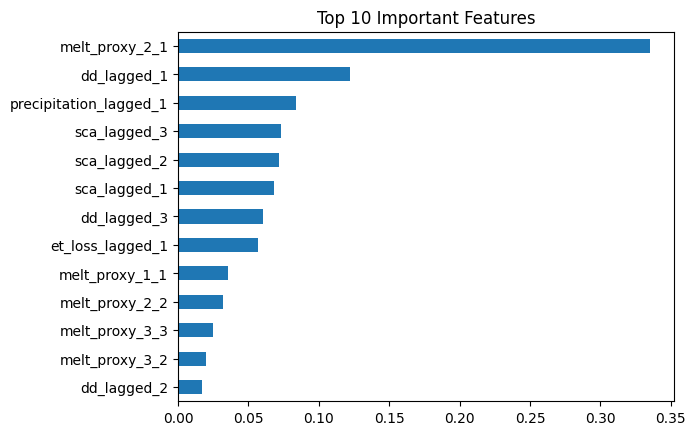

sca_lagged_1              0.068449
dd_lagged_1               0.121854
sca_lagged_2              0.071413
dd_lagged_2               0.016914
sca_lagged_3              0.073260
dd_lagged_3               0.060024
et_loss_lagged_1          0.056831
precipitation_lagged_1    0.083738
melt_proxy_1_1            0.035531
melt_proxy_2_1            0.335609
melt_proxy_2_2            0.031654
melt_proxy_3_2            0.019766
melt_proxy_3_3            0.024958
dtype: float32

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get scores and match them with feature names
feat_importances = pd.Series(xgb2.feature_importances_, index=X_train_ml.columns)

# 2. Plot the top 10 features
feat_importances.nlargest(20).sort_values().plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()
feat_importances

In [ ]:
import shap
# Xd = xgboost.DMatrix(X, label=y)

# explainer = shap.TreeExplainer(xgb1)
# explanation = explainer(X_train_ml)
# shap_values = explanation.values
explainer = shap.Explainer(xgb2)
shap_values = explainer(X_train_ml)

shap.plots.waterfall(shap_values[0])


In [ ]:
from shap import initjs


initjs()

In [ ]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0])

In [ ]:
# visualize all the training set predictions
shap.plots.force(shap_values[:500])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the dark theme to match your MapLibre UI
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Use the test-series index (ensure datetime) as x-axis.
# df1 does not have a 'date' column because the dataframe was set_index('date') earlier.
date = pd.to_datetime(y_test_true.index)

# Ensure predictions are 1D arrays aligned with the date index
y_test_pred_plot = np.asarray(y_test_pred).ravel()
q_hybrid_plot = np.asarray(q_hybrid_testf).ravel()

# Plotting the three curves
ax.plot(date, y_test_true, label='Observed Discharge', color='#ffffff', linewidth=1.5, alpha=0.8)
ax.plot(date, y_test_pred_plot, label='Baseline Model', color='#ff4b4b', linestyle='--', linewidth=1.2)
ax.plot(date, q_hybrid_plot, label='Hybrid AI Model', color='#00d4ff', linewidth=2.5)

# Highlighting the "Peak Capture"
# You can shade the summer months where the SCA-melt logic is most active
# ax.axvspan('2023-06-01', '2023-08-31', color='#00d4ff', alpha=0.05, label='Peak Melt Season')

# Formatting
ax.set_title('Tarbela Inflow Prediction: Test Period Performance', loc='left', fontsize=16, pad=20)
ax.set_ylabel('Discharge ($m^3/s$)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('hydrograph_performance.png', transparent=True)

In [ ]:

# In order of priority:

# Observed vs predicted hydrograph — most important, get this first
# Scatter plot with R² — quick to make once you have predictions exported
# Feature importance bar chart — you have the values already, just needs a clean plot
# Bias correction table — pull your Besham validation numbers

In [ ]:
# # Verify this:
# # ensure the DataFrame index is a DatetimeIndex before using .year
# df.index = pd.to_datetime(df.index)

# print(df[df.index.year == 2022]['precipitation'].mean())
# print(df[df.index.year.isin([2010,2015,2020])]['precipitation'].mean())

# # Was 2022 precipitation anomalously low?

In [ ]:
# # 1. Compare 2022 to 2002 conditions

# low_flow_years = df[df.index.year.isin([2002, 2022])]
# normal_years = df[df.index.year.isin([2015, 2018])]

# print("Low flow years mean precip:", low_flow_years['precipitation'].mean())
# print("Normal years mean precip:", normal_years['precipitation'].mean())

# # 2. Check SCA (snow cover)
# print("2022 max SCA:", df[df.index.year == 2022]['sca'].max())
# print("Typical max SCA:", df['sca'].quantile(0.75))

# # 3. Residual analysis
# df_adv['residual'] = df_adv['baseline_q'] - q_hybrid_testf
# print("\n2022 residuals:")
# # align baseline and hybrid predictions with the test index and show 2022 rows
# baseline_series = pd.Series(y_test_pred.ravel(), index=y_test_true.index, name='Q_pred')
# hybrid_series = pd.Series(q_hybrid_testf, index=y_test_true.index, name='Q_hybrid')

# df_2022 = pd.DataFrame({
#     'Q_obs': y_test_true,
#     'Q_pred': baseline_series,
#     'Q_hybrid': hybrid_series,
# })
# df_2022.index = pd.to_datetime(df_2022.index)

# df_2022['residual'] = df_2022['Q_obs'] - df_2022['Q_hybrid']

# print(df_2022[df_2022.index.year == 2022])

# # Are residuals consistently negative (underestimation)?

In [ ]:
# # Compare 2022 summer temperatures to other years
# summer_2022_dd = df[(df.index >= '2022-06-01') & (df.index <= '2022-08-31')]['dd'].mean()
# summer_typical = df[(df.index.month.isin([6,7,8]))]['dd'].mean()

# print(f"2022 summer DD: {summer_2022_dd}")
# print(f"Typical summer DD: {summer_typical}")

# # If 2022 summer was COOLER, that explains it!

In [ ]:
# from sklearn.model_selection import GridSearchCV
# import xgboost as xgb

# # Define the parameter grid
# # You can expand this grid to tune other parameters as well
# param_grid = {
#     'max_depth': [3, 4, 5, 6, 7],
#     'n_estimators': range(100,1500, 100),
#     'learning_rate': [0.01, 0.1, 0.2]
# }

# # Initialize the XGBoost regressor
# xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# # Initialize GridSearchCV
# # We use 'neg_root_mean_squared_error' as the scoring metric.
# # GridSearchCV maximizes the score, so it minimizes RMSE.
# grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, 
#                            cv=3, n_jobs=-1, verbose=2, scoring='neg_root_mean_squared_error')

# # Fit GridSearchCV
# # Note: This can take some time to run
# grid_search.fit(X_train_ml, y_train_ml)

# # Print the best parameters found
# print(f"Best parameters found: {grid_search.best_params_}")

# # You can now use the best estimator for prediction
# best_xgb_model = grid_search.best_estimator_

LSTM NSE (Test): 0.6951
LSTM R²  (Test): 0.6951


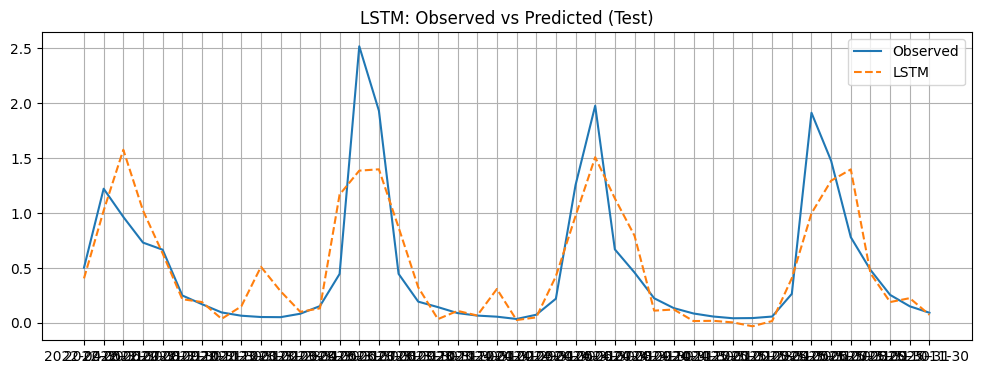

In [29]:
# --- LSTM baseline on the same leakage-free lagged splits ---
# Uses X_train_lagged / X_val_lagged / X_test_lagged and Y_*_lagged created above.

import numpy as np
import pandas as pd

# Try TensorFlow/Keras; if unavailable, fail with a clear error message
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except Exception as e:
    raise ImportError(
        "TensorFlow is required for the LSTM cell. Install it (e.g., `pip install tensorflow`) and rerun."
    ) from e

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1) Scale features based on train only (no leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lagged)
X_val_scaled = scaler.transform(X_val_lagged)
X_test_scaled = scaler.transform(X_test_lagged)

# 2) Reshape to (samples, timesteps, features)
# Here we treat each row as a 1-timestep sequence (since we already encoded history via lag features)
X_train_seq = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_seq = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_seq = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Targets
y_train = Y_train_lagged['runoff'].values.astype(np.float32)
y_val = Y_val_lagged['runoff'].values.astype(np.float32)
y_test = Y_test_lagged['runoff'].values.astype(np.float32)

# 3) Define a small LSTM (kept intentionally simple to avoid overfitting)
# NOTE: This is a quick diagnostic baseline, not a fully tuned deep model.
tf.keras.utils.set_random_seed(42)

model = models.Sequential([
    layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
]

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=1500,
    batch_size=64,
    verbose=0,
    callbacks=callbacks
)

# 4) Evaluate on test
y_pred_test = model.predict(X_test_seq, verbose=0).ravel()

lstm_nse = calculate_nse(y_test, y_pred_test)
lstm_r2 = r2_score(y_test, y_pred_test)

print(f"LSTM NSE (Test): {lstm_nse:.4f}")
print(f"LSTM R²  (Test): {lstm_r2:.4f}")

# Optional quick visual check
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(Y_test_lagged.index, y_test, label='Observed')
plt.plot(Y_test_lagged.index, y_pred_test, label='LSTM', linestyle='--')
plt.title('LSTM: Observed vs Predicted (Test)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Verify correlations NOW with fixed DD:
print("Correlations with runoff (fixed DD):")
print(df[['precipitation', 'sca_lagged', 'dd', 'et_loss', 'runoff']].corr()['runoff'])

# Expected:
# precipitation: +0.3 to +0.5
# sca (lagged): +0.4 to +0.6
# dd (lagged): +0.4 to +0.7
# et_loss: -0.1 to -0.3

# If still seeing negative/weak correlations, data is STILL wrong!

In [ ]:
# After fixing DD misalignment:
import matplotlib.pyplot as plt
# 1. Plot time series
fig, axes = plt.subplots(4, 1, figsize=(302, 40))

axes[0].plot(df.index, df['runoff'], label='Runoff')
axes[0].set_title('Runoff')

axes[1].plot(df.index, df['precipitation'], label='Precipitation')
axes[1].set_title('Precipitation')

axes[2].plot(df.index, df['sca'], label='SCA')
axes[2].plot(df.index, df['dd'], label='DD', alpha=0.7)
axes[2].set_title('SCA and DD')
axes[2].legend()

axes[3].plot(df.index, df['sca'] * df['dd'], label='SCA × DD', color='red')
axes[3].set_title('Melt Proxy (SCA × DD)')

plt.tight_layout()
plt.show()

# Does SCA × DD peak in summer when runoff peaks?
# If not, data STILL wrong!

In [ ]:
# --- Diagnostic: is dd defined correctly, and what lag makes physical sense? ---
import numpy as np
import pandas as pd

# Ensure datetime index for seasonal grouping
_df = df.copy()
_df.index = pd.to_datetime(_df.index)

print('dd quick sanity:')
print(_df['dd'].describe())

# If temp exists, dd should generally be positively correlated with temp
if 'temp' in _df.columns:
    print('\nCorr(temp, dd):', _df[['temp', 'dd']].corr().loc['temp', 'dd'])
else:
    print("\nNo 'temp' column found; skipping Corr(temp, dd) check.")

# Check correlation of dd with month-of-year (seasonality proxy)
month = _df.index.month
print('Corr(month, dd):', pd.Series(month, index=_df.index).corr(_df['dd']))

# Correlations vs runoff for multiple lags
max_lag = 12
corrs_dd = {}
corrs_sca = {}
corrs_melt = {}

for L in range(0, max_lag + 1):
    dd_L = _df['dd'].shift(L)
    sca_L = _df['sca'].shift(L)
    melt_L = (sca_L * dd_L)

    corrs_dd[L] = dd_L.corr(_df['runoff'])
    corrs_sca[L] = sca_L.corr(_df['runoff'])
    corrs_melt[L] = melt_L.corr(_df['runoff'])

corr_table = pd.DataFrame({
    'corr(dd_lag, runoff)': pd.Series(corrs_dd),
    'corr(sca_lag, runoff)': pd.Series(corrs_sca),
    'corr(sca_lag*dd_lag, runoff)': pd.Series(corrs_melt),
}).sort_index()

print('\nLag correlation scan (higher + is more physically consistent for melt season):')
display(corr_table)

best_dd_lag = corr_table['corr(dd_lag, runoff)'].idxmax()
best_melt_lag = corr_table['corr(sca_lag*dd_lag, runoff)'].idxmax()

print(f"\nBest lag for dd vs runoff (by max corr): L={best_dd_lag} (corr={corr_table.loc[best_dd_lag, 'corr(dd_lag, runoff)']:.3f})")
print(f"Best lag for melt proxy vs runoff (by max corr): L={best_melt_lag} (corr={corr_table.loc[best_melt_lag, 'corr(sca_lag*dd_lag, runoff)']:.3f})")

# Interpretation helper
print('\nInterpretation hints:')
print('- If Corr(temp, dd) is strongly negative, dd is likely sign-inverted / computed as a deficit.')
print('- If dd correlations are negative at all lags but sca_lag correlations are positive, dd may not represent melt energy as intended.')
print('- If dd becomes positive at a specific lag, you likely have a timing mismatch (runoff responds after L months).')


In [ ]:
# --- Diagnostic: cross-lag melt interactions (SCA storage × DD energy) ---
# Goal: find which combinations sca(t-i) * dd(t-j) align best with runoff(t)
# Interpretable expectation: i (SCA lag) can be a few months (snow storage),
# while j (DD lag) should be ~0-1 months (current melt energy).

import numpy as np
import pandas as pd

_df = df.copy()
_df.index = pd.to_datetime(_df.index)

# How many months back to scan
max_sca_lag = 12
max_dd_lag = 12

rows = []
for i in range(0, max_sca_lag + 1):
    sca_i = _df['sca'].shift(i)
    for j in range(0, max_dd_lag + 1):
        dd_j = _df['dd'].shift(j)
        feat = sca_i * dd_j
        c = feat.corr(_df['runoff'])
        rows.append({
            'sca_lag': i,
            'dd_lag': j,
            'corr(sca_lag*dd_lag, runoff)': c,
        })

cross_lag_table = pd.DataFrame(rows)

# Rank by absolute correlation and by positive correlation separately
cross_lag_table_pos = cross_lag_table.sort_values('corr(sca_lag*dd_lag, runoff)', ascending=False)
cross_lag_table_abs = cross_lag_table.reindex(
    cross_lag_table['corr(sca_lag*dd_lag, runoff)'].abs().sort_values(ascending=False).index
)

print('Top 15 cross-lag interactions by POSITIVE correlation:')
display(cross_lag_table_pos.head(15))

print('Top 15 cross-lag interactions by ABS(correlation) (useful to spot sign flips):')
display(cross_lag_table_abs.head(15))

# Physically plausible subset: DD lag 0-1, SCA lag 0-6
phys_subset = cross_lag_table[(cross_lag_table['dd_lag'].isin([0, 1])) & (cross_lag_table['sca_lag'] <= 6)]
phys_subset = phys_subset.sort_values('corr(sca_lag*dd_lag, runoff)', ascending=False)

print('Top 10 PHYSICALLY PLAUSIBLE interactions (dd_lag in {0,1}, sca_lag<=6):')
display(phys_subset.head(10))

best_phys = phys_subset.iloc[0]
print(
    f"Best phys-plausible interaction: sca_lag={int(best_phys['sca_lag'])}, "
    f"dd_lag={int(best_phys['dd_lag'])}, corr={best_phys['corr(sca_lag*dd_lag, runoff)']:.3f}"
)

# Convenience: build a suggested feature list for subsequent models
suggested_sca_lags = [1, 2, 3, 4]  # storage memory
suggested_dd_lags = [0, 1]         # melt energy near-current

suggested_interactions = []
for i in suggested_sca_lags:
    for j in suggested_dd_lags:
        suggested_interactions.append((i, j))

print('\nSuggested interaction features to try next:')
for i, j in suggested_interactions:
    print(f" - melt_proxy_scaL{i}_ddL{j} = sca(t-{i}) * dd(t-{j})")

# Create these features in a small frame (no leakage implications here; still must split before creating lags when training)
# This is for quick inspection only.
features_preview = pd.DataFrame(index=_df.index)
for i, j in suggested_interactions:
    features_preview[f'melt_proxy_scaL{i}_ddL{j}'] = _df['sca'].shift(i) * _df['dd'].shift(j)

print('\nCorrelation of suggested interaction features with runoff:')
display(features_preview.join(_df['runoff']).corr(numeric_only=True)[['runoff']].sort_values('runoff', ascending=False).head(15))


In [ ]:
# Build model WITHOUT seasonality but WITH proper physics:

# Create INTERACTION term:
df['melt_proxy'] = df['sca'].shift(2) * df['dd'].shift(1)  # Same lag!

# Baseline WITHOUT seasonality:
X = df[['precipitation_lagged', 'melt_proxy', 'et_loss_lagged']]
y = df['runoff']

# Split and fit
model = LinearRegression()
# build fresh leakage-free splits from X,y (drop NaNs first)
df_xy = pd.concat([X, y], axis=1).dropna()
X_clean = df_xy[X.columns]
y_clean = df_xy['runoff']

# time-based splits (same as elsewhere in notebook)
X_train_lagged = X_clean[:'2017-12-31']
X_val_lagged   = X_clean['2018-01-01':'2021-12-31']
X_test_lagged  = X_clean['2022-01-01':]

Y_train_lagged = y_clean[:'2017-12-31'].to_frame()
Y_val_lagged   = y_clean['2018-01-01':'2021-12-31'].to_frame()
Y_test_lagged  = y_clean['2022-01-01':].to_frame()

# fit on the training partition only
model.fit(X_train_lagged, Y_train_lagged)

nse_no_season = calculate_nse(Y_test_lagged, model.predict(X_test_lagged))
# ensure scalar for formatting
try:
    nse_val = float(np.squeeze(nse_no_season))
except Exception:
    try:
        nse_val = float(nse_no_season.iloc[0])
    except Exception:
        nse_val = nse_no_season

print(f"NSE without seasonality: {nse_val:.3f}")
model.coef_
# Expected if physics works: 0.5-0.6
# If still 0.3: Data/features still broken